# Fresh Food Access Dashboard Build Notebook

This notebook prepares a tract-level dataset for the Atlanta fresh food access dashboard using tract geometry, LILA indicators, MARTA access, and food business counts.


## 1. Imports


In [597]:
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


## 2. Paths


In [598]:
ROOT = Path.cwd().resolve().parent
DATA = ROOT / 'data'

ATL_PATH = DATA / 'atl' / 'Census2020_Tracts_COA.geojson'
LILA_PATH = DATA / 'lila' / 'lila_halfmi_census.shp'
BUS_PATH = DATA / 'bus_lic' / 'bus_lic.xlsx'
MARTA_ROUTES_PATH = DATA / 'marta' / 'MARTA_Routes.geojson'

OUTPUT_PATH = DATA / 'processed' / 'tract_level_food_access.geojson'
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)


## 3. Load tract geometry


In [599]:
atl = gpd.read_file(ATL_PATH).to_crs(epsg=4326)
atl.head()


,FID,GEOID,NAME,County_Nam,State_Name,P0010001,Longitude,Latitude,Shape__Are,Shape__Len,NPU,Shape__Area,Shape__Length,geometry
0,1,13121010307,Census Tract 103.07,Fulton County,Georgia,5425,-9.411489e+06,3.980673e+06,1.534330e+07,19185.041477,,1.534330e+07,19185.041477,"POLYGON ((-84.5659 33.64711, -84.56586 33.6472..."
1,2,13121011306,Census Tract 113.06,Fulton County,Georgia,3371,-9.406914e+06,3.980658e+06,1.038947e+07,16111.869887,,1.038947e+07,16111.869887,"POLYGON ((-84.52162 33.65584, -84.52143 33.655..."
2,3,13121006000,Census Tract 60,Fulton County,Georgia,3140,-9.399711e+06,3.993669e+06,2.270683e+06,7679.561985,,2.270683e+06,7679.561985,"POLYGON ((-84.44736 33.73455, -84.4472 33.7354..."
3,4,13121006100,Census Tract 61,Fulton County,Georgia,3269,-9.399488e+06,3.992305e+06,3.256851e+06,8565.052953,,3.256851e+06,8565.052953,"POLYGON ((-84.45043 33.72352, -84.4502 33.7242..."
4,5,13121007602,Census Tract 76.02,Fulton County,Georgia,2309,-9.402284e+06,3.990050e+06,4.882680e+06,12249.788746,,4.882680e+06,12249.788746,"POLYGON ((-84.47687 33.70507, -84.47685 33.706..."


## 4. Inspect tract columns


In [600]:
print(atl.columns.tolist())


['FID', 'GEOID', 'NAME', 'County_Nam', 'State_Name', 'P0010001', 'Longitude', 'Latitude', 'Shape__Are', 'Shape__Len', 'NPU', 'Shape__Area', 'Shape__Length', 'geometry']


## 5. Create master tract dataframe
This uses `TRACTCE` as the tract key. Change it if your tract file uses a different field.


In [601]:
tracts = atl.copy()
tracts['tract_id'] = tracts['NAME'].astype(str).str.zfill(6)
tracts = tracts[['tract_id', 'geometry'] + [c for c in tracts.columns if c not in ['tract_id', 'geometry']]]
tracts.head()


,tract_id,geometry,FID,GEOID,NAME,County_Nam,State_Name,P0010001,Longitude,Latitude,Shape__Are,Shape__Len,NPU,Shape__Area,Shape__Length
0,Census Tract 103.07,"POLYGON ((-84.5659 33.64711, -84.56586 33.6472...",1,13121010307,Census Tract 103.07,Fulton County,Georgia,5425,-9.411489e+06,3.980673e+06,1.534330e+07,19185.041477,,1.534330e+07,19185.041477
1,Census Tract 113.06,"POLYGON ((-84.52162 33.65584, -84.52143 33.655...",2,13121011306,Census Tract 113.06,Fulton County,Georgia,3371,-9.406914e+06,3.980658e+06,1.038947e+07,16111.869887,,1.038947e+07,16111.869887
2,Census Tract 60,"POLYGON ((-84.44736 33.73455, -84.4472 33.7354...",3,13121006000,Census Tract 60,Fulton County,Georgia,3140,-9.399711e+06,3.993669e+06,2.270683e+06,7679.561985,,2.270683e+06,7679.561985
3,Census Tract 61,"POLYGON ((-84.45043 33.72352, -84.4502 33.7242...",4,13121006100,Census Tract 61,Fulton County,Georgia,3269,-9.399488e+06,3.992305e+06,3.256851e+06,8565.052953,,3.256851e+06,8565.052953
4,Census Tract 76.02,"POLYGON ((-84.47687 33.70507, -84.47685 33.706...",5,13121007602,Census Tract 76.02,Fulton County,Georgia,2309,-9.402284e+06,3.990050e+06,4.882680e+06,12249.788746,,4.882680e+06,12249.788746


## 6. Load LILA data and inspect columns


In [602]:
lila = gpd.read_file(LILA_PATH).to_crs(epsg=4326)
print(lila.columns.tolist())
lila.head()


['CnssTrc', 'State', 'County', 'LILAT_1A1', 'LILAT_A', 'LILAT_1A2', 'LILAT_V', 'PvrtyRt', 'MdnFmlI', 'LAhlf10', 'LATrct_', 'TrcSNAP', 'tract', 'STATEFP', 'COUNTYF', 'TRACTCE', 'BLOCKCE', 'BLOCKID', 'PARTFLG', 'HOUSING', 'POP10', 'geometry']


,CnssTrc,State,County,LILAT_1A1,LILAT_A,LILAT_1A2,LILAT_V,PvrtyRt,MdnFmlI,LAhlf10,...,tract,STATEFP,COUNTYF,TRACTCE,BLOCKCE,BLOCKID,PARTFLG,HOUSING,POP10,geometry
0,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1060,131210006001060,N,329,342,"POLYGON ((-84.40747 33.78225, -84.40748 33.781..."
1,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1054,131210006001054,N,7,20,"POLYGON ((-84.40419 33.78154, -84.4043 33.7817..."
2,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1053,131210006001053,N,23,26,"POLYGON ((-84.40263 33.78153, -84.40273 33.781..."
3,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1074,131210006001074,N,0,0,"POLYGON ((-84.41343 33.78159, -84.41341 33.781..."
4,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1070,131210006001070,N,0,0,"POLYGON ((-84.41069 33.78062, -84.41243 33.780..."


## 7. Spatially join LILA indicators to Atlanta tracts
This keeps the tract geometry and brings in tract-level food access and socioeconomic fields from the LILA layer.


In [603]:
lila_cols_to_keep = [
    'PvrtyRt',
    'TrcSNAP',
    'LAhalf10',
    'LILAT_1A1',
    'LILAT_A',
    'LILAT_1A2',
    'LILAT_V',
    'geometry'
]

available_lila_cols = [c for c in lila_cols_to_keep if c in lila.columns]
lila_subset = lila[available_lila_cols].copy()

lila_join = gpd.sjoin(
    tracts[['tract_id', 'geometry']],
    lila_subset,
    how='left',
    predicate='intersects'
)

lila_join = lila_join.drop(columns=[c for c in ['index_right'] if c in lila_join.columns])
lila_join.head()


,tract_id,geometry,PvrtyRt,TrcSNAP,LILAT_1A1,LILAT_A,LILAT_1A2,LILAT_V
0,Census Tract 103.07,"POLYGON ((-84.5659 33.64711, -84.56586 33.6472...",19.952568,1300.0,1.0,1.0,1.0,1.0
0,Census Tract 103.07,"POLYGON ((-84.5659 33.64711, -84.56586 33.6472...",19.952568,1300.0,1.0,1.0,1.0,1.0
0,Census Tract 103.07,"POLYGON ((-84.5659 33.64711, -84.56586 33.6472...",19.952568,1300.0,1.0,1.0,1.0,1.0
0,Census Tract 103.07,"POLYGON ((-84.5659 33.64711, -84.56586 33.6472...",19.952568,1300.0,1.0,1.0,1.0,1.0
0,Census Tract 103.07,"POLYGON ((-84.5659 33.64711, -84.56586 33.6472...",19.952568,1300.0,1.0,1.0,1.0,1.0


## 8. Collapse joined LILA records to one row per tract
For numeric indicators, this takes the max across intersecting LILA shapes.


In [604]:
numeric_lila_cols = [
    c for c in ['PvrtyRt', 'TrcSNAP', 'LAhalf10', 'LILAT_1A1', 'LILAT_A', 'LILAT_1A2', 'LILAT_V']
    if c in lila_join.columns
]

lila_summary = (
    lila_join.groupby('tract_id')[numeric_lila_cols]
    .max()
    .reset_index()
)

tracts = tracts.merge(lila_summary, on='tract_id', how='left')
tracts[numeric_lila_cols + ['tract_id']].head()


,PvrtyRt,TrcSNAP,LILAT_1A1,LILAT_A,LILAT_1A2,LILAT_V,tract_id
0,22.869456,1300.0,1.0,1.0,1.0,1.0,Census Tract 103.07
1,23.514263,1300.0,1.0,1.0,1.0,1.0,Census Tract 113.06
2,32.371933,1206.0,1.0,1.0,1.0,1.0,Census Tract 60
3,28.347280,541.0,1.0,1.0,1.0,1.0,Census Tract 61
4,35.356201,644.0,1.0,1.0,1.0,1.0,Census Tract 76.02


## 9. Build a simple combined LILA flag
This is useful for mapping and scoring.


In [605]:
lila_flag_cols = [c for c in ['LILAT_1A1', 'LILAT_A', 'LILAT_1A2', 'LILAT_V'] if c in tracts.columns]

for col in lila_flag_cols:
    tracts[col] = pd.to_numeric(tracts[col], errors='coerce').fillna(0)

tracts['has_lila'] = (tracts[lila_flag_cols].sum(axis=1) > 0).astype(int)
tracts[['tract_id', 'has_lila'] + lila_flag_cols].head()


,tract_id,has_lila,LILAT_1A1,LILAT_A,LILAT_1A2,LILAT_V
0,Census Tract 103.07,1,1.0,1.0,1.0,1.0
1,Census Tract 113.06,1,1.0,1.0,1.0,1.0
2,Census Tract 60,1,1.0,1.0,1.0,1.0
3,Census Tract 61,1,1.0,1.0,1.0,1.0
4,Census Tract 76.02,1,1.0,1.0,1.0,1.0


## 10. Load and inspect business license data


In [606]:
bus = pd.read_csv("../data/bus_lic/bus_lic.csv", encoding="latin1")
print(bus.columns.tolist())
bus.head()


['license_number', 'company_name', 'company_dba', 'license_classification', 'issued_date', 'naics_code', 'naics_name', 'predirection', 'address_line1', 'address_line2', 'street_type', 'postdirection', 'unit_suite', 'city', 'state', 'postal_code', 'address_concat', 'address_api', 'longitude', 'latitude', 'disinvested_neighborhood', 'council_district', 'npu']


,license_number,company_name,company_dba,license_classification,issued_date,naics_code,naics_name,predirection,address_line1,address_line2,...,city,state,postal_code,address_concat,address_api,longitude,latitude,disinvested_neighborhood,council_district,npu
0,GBL-0121-00257,H & H Interiors LLC,NaN,Other Services except Public Administration,2025-01-07 13:21:16,541410.0,Interior Design Services,NE,2652 Forrest,NaN,...,Atlanta,GA,NaN,2652 Forrest nan WAY Atlanta GA nan,"2652 Forrest Way NE, Atlanta, Georgia, 30305",-84.379893,33.827640,False,7,B
1,GBL-0121-00258,One Lion Studios LLC,NaN,Other Services except Public Administration,2025-02-16 18:39:21,541840.0,Media Representatives,NaN,3343 Peachtree Rd NE,NaN,...,Atlanta,GA,30326,3343 Peachtree Rd NE nan nan Atlanta GA 30326,"3343 Peachtree Rd NE, Atlanta, Georgia, 30326",-84.367109,33.846760,False,7,B
2,GBL-0121-00272,Destingkt Designs LLC,NaN,Other Services except Public Administration,2025-03-04 23:04:54,541410.0,Interior Design Services,NaN,931,PONCE DE LEON,...,Atlanta,GA,NaN,931 PONCE DE LEON AVE Atlanta GA nan,"931 Ponce de Leon Ave NE, Atlanta, Georgia, 30306",-84.356939,33.773524,False,2,N
3,GBL-0121-00274,Mac Cigars LLC,J's Cigars,Retail Trade,2025-02-25 23:09:11,453991.0,Tobacco Stores,NaN,2072,Defoors Ferry,...,Atlanta,GA,30318,2072 Defoors Ferry RD Atlanta GA 30318,"2072 Defoors Ferry Rd NW, Atlanta, Georgia, 30318",-84.426318,33.812071,False,9,D
4,GBL-0121-00283,Essence of She Day Spa Salon,NaN,Other Services except Public Administration,2025-01-09 19:04:31,812112.0,Beauty Salons,NaN,144,MORELAND,...,ATLANTA,GA,30307,144 MORELAND AVE ATLANTA GA 30307,"144 Moreland Ave NE, Atlanta, Georgia, 30307",-84.349501,33.756604,False,5,N


## 11. Count food-related businesses by tract
Edit the business type and coordinate column names here after checking your file.


In [607]:
BUSINESS_TYPE_COL = 'naics_name'
LON_COL = 'longitude'
LAT_COL = 'latitude'

food_keywords = ['grocery', 'supermarket', 'market', 'produce', 'food', 'corner store']


bus['business_type_clean'] = bus[BUSINESS_TYPE_COL].astype(str).str.lower()
food_bus = bus[bus['business_type_clean'].str.contains('|'.join(food_keywords), na=False)].copy()
food_bus = food_bus.dropna(subset=[LON_COL, LAT_COL]).copy()

food_bus_gdf = gpd.GeoDataFrame(
     food_bus,
     geometry=gpd.points_from_xy(food_bus[LON_COL], food_bus[LAT_COL]),
     crs='EPSG:4326'
 )

bus_join = gpd.sjoin(
     food_bus_gdf,
     tracts[['tract_id', 'geometry']],
     how='left',
    predicate='within'
)
business_counts = bus_join.groupby('tract_id').size().reset_index(name='food_business_count')
tracts = tracts.merge(business_counts, on='tract_id', how='left')
tracts['food_business_count'] = tracts['food_business_count'].fillna(0)


## 12. Load MARTA routes and count tract access


In [608]:
marta = gpd.read_file(MARTA_ROUTES_PATH).to_crs(epsg=4326)
print(marta.columns.tolist())

marta_join = gpd.sjoin(
    tracts[['tract_id', 'geometry']],
    marta,
    how='left',
    predicate='intersects'
)

marta_counts = marta_join.groupby('tract_id').size().reset_index(name='marta_access_count')
tracts = tracts.merge(marta_counts, on='tract_id', how='left')
tracts['marta_access_count'] = tracts['marta_access_count'].fillna(0)
tracts[['tract_id', 'marta_access_count']].head()


['OBJECTID', 'shape_id', 'OBJECTID_1', 'route_id', 'trip_id', 'shape_id_1', 'OBJECTID_12', 'route_id_1', 'route_short_name', 'route_long_name', 'route_type', 'route_color', 'Shape__Length', 'geometry']


,tract_id,marta_access_count
0,Census Tract 103.07,5
1,Census Tract 113.06,19
2,Census Tract 60,10
3,Census Tract 61,4
4,Census Tract 76.02,8


## 13. Clean and inspect the scoring columns


In [609]:
candidate_cols = ['PvrtyRt', 'TrcSNAP', 'LAhalf10', 'has_lila', 'food_business_count', 'marta_access_count']

for col in candidate_cols:
    if col not in tracts.columns:
        tracts[col] = 0
    tracts[col] = pd.to_numeric(tracts[col], errors='coerce').fillna(0)

tracts[candidate_cols].describe()


,PvrtyRt,TrcSNAP,LAhalf10,has_lila,food_business_count,marta_access_count
count,211.000000,211.000000,211.0,211.000000,211.000000,211.000000
mean,24.120566,358.559242,0.0,0.597156,2.459716,11.739336
std,22.718969,414.125470,0.0,0.491636,3.540519,9.865926
min,0.000000,0.000000,0.0,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.0,0.000000,0.000000,6.000000
50%,24.508600,247.000000,0.0,1.000000,1.000000,10.000000
75%,43.258992,586.000000,0.0,1.000000,4.000000,15.500000
max,79.797535,1300.000000,0.0,1.000000,35.000000,69.000000


## 14. Check whether `TrcSNAP` and `PvrtyRt` need rescaling
If the max is above 1, divide by 100.


In [610]:
if tracts['TrcSNAP'].max() > 1:
    tracts['TrcSNAP'] = tracts['TrcSNAP'] / 100

if tracts['PvrtyRt'].max() > 1:
    tracts['PvrtyRt'] = tracts['PvrtyRt'] / 100

tracts[['TrcSNAP', 'PvrtyRt']].describe()


,TrcSNAP,PvrtyRt
count,211.000000,211.000000
mean,3.585592,0.241206
std,4.141255,0.227190
min,0.000000,0.000000
25%,0.000000,0.000000
50%,2.470000,0.245086
75%,5.860000,0.432590
max,13.000000,0.797975


## 15. Normalize variables for scoring


In [611]:
score_cols = ['TrcSNAP', 'PvrtyRt', 'LAhalf10', 'food_business_count', 'marta_access_count']
scaler = MinMaxScaler()
scaled = scaler.fit_transform(tracts[score_cols])

for i, col in enumerate(score_cols):
    tracts[f'{col}_scaled'] = scaled[:, i]

tracts['food_business_gap'] = 1 - tracts['food_business_count_scaled']
tracts['transit_gap'] = 1 - tracts['marta_access_count_scaled']

tracts[[f'{c}_scaled' for c in score_cols] + ['food_business_gap', 'transit_gap']].head()


,TrcSNAP_scaled,PvrtyRt_scaled,LAhalf10_scaled,food_business_count_scaled,marta_access_count_scaled,food_business_gap,transit_gap
0,1.000000,0.286594,0.0,0.000000,0.058824,1.000000,0.941176
1,1.000000,0.294674,0.0,0.000000,0.264706,1.000000,0.735294
2,0.927692,0.405676,0.0,0.057143,0.132353,0.942857,0.867647
3,0.416154,0.355240,0.0,0.028571,0.044118,0.971429,0.955882
4,0.495385,0.443074,0.0,0.000000,0.102941,1.000000,0.897059


## 16. Build a tract need score


In [612]:
tracts['need_score'] = (
    0.30 * tracts['TrcSNAP_scaled'] +
    0.25 * tracts['PvrtyRt_scaled'] +
    0.20 * tracts['LAhalf10_scaled'] +
    0.15 * tracts['food_business_gap'] +
    0.10 * tracts['transit_gap']
)

tracts['priority_level'] = pd.qcut(
    tracts['need_score'].rank(method='first'),
    q=4,
    labels=['Low', 'Moderate', 'High', 'Very High']
)

tracts[['tract_id', 'need_score', 'priority_level']].sort_values('need_score', ascending=False).head(10)


,tract_id,need_score,priority_level
17,Census Tract 79,0.736063,Very High
22,Census Tract 112.03,0.699775,Very High
23,Census Tract 112.04,0.695364,Very High
18,Census Tract 80,0.688383,Very High
73,Census Tract 66.01,0.685420,Very High
5,Census Tract 76.03,0.668151,Very High
14,Census Tract 78.06,0.664298,Very High
89,Census Tract 108.02,0.662726,Very High
84,Census Tract 73.01,0.658440,Very High
29,Census Tract 78.08,0.655978,Very High


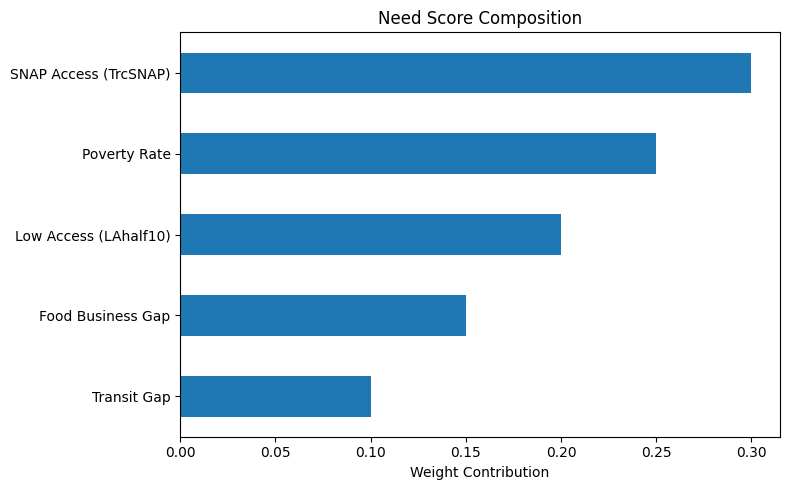

In [613]:
import pandas as pd
import matplotlib.pyplot as plt

weights = pd.Series({
    'SNAP Access (TrcSNAP)': 0.30,
    'Poverty Rate': 0.25,
    'Low Access (LAhalf10)': 0.20,
    'Food Business Gap': 0.15,
    'Transit Gap': 0.10
})

weights = weights.sort_values()

plt.figure(figsize=(8,5))
weights.plot(kind='barh')

plt.xlabel('Weight Contribution')
plt.title('Need Score Composition')

plt.tight_layout()
plt.show()

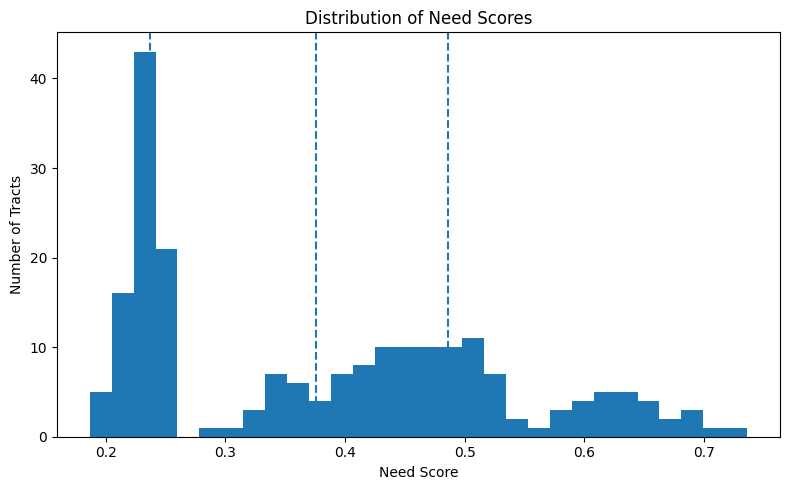

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(tracts['need_score'], bins=30)


for q in tracts['need_score'].quantile([0.25, 0.5, 0.75]):
    plt.axvline(q, linestyle='--')

plt.title('Distribution of Need Scores')
plt.xlabel('Need Score')
plt.ylabel('Number of Tracts')

plt.tight_layout()
plt.show()

## 17. Save the processed tract-level file


In [615]:
tracts.to_file(OUTPUT_PATH, driver='GeoJSON')
print(f'Saved to: {OUTPUT_PATH}')


Saved to: /Users/savannahimani/FreshFoodAccess_Project/FreshFoodAcessDashboard-InvestATL/data/processed/tract_level_food_access.geojson


## 18. Quick map check


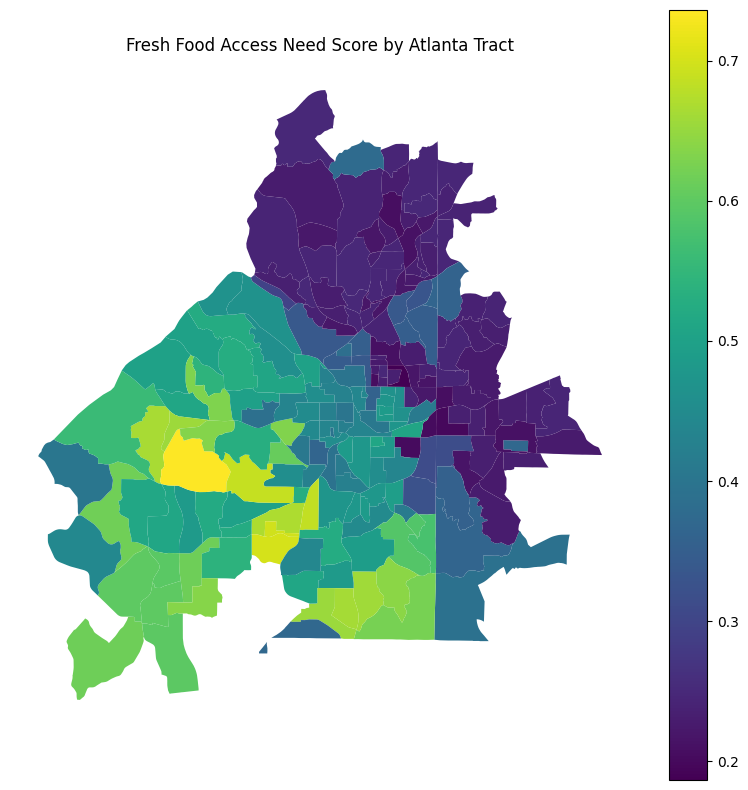

In [616]:
fig, ax = plt.subplots(figsize=(10, 10))
tracts.plot(column='need_score', legend=True, ax=ax)
ax.set_title('Fresh Food Access Need Score by Atlanta Tract')
ax.set_axis_off()
plt.show()


In [617]:
top_tracts = (
    tracts[['tract_id', 'need_score', 'PvrtyRt', 'TrcSNAP', 'LAhalf10', 'marta_access_count']]
    .sort_values('need_score', ascending=False)
    .head(10)
)

top_tracts

,tract_id,need_score,PvrtyRt,TrcSNAP,LAhalf10,marta_access_count
17,Census Tract 79,0.736063,0.714767,12.06,0,12
22,Census Tract 112.03,0.699775,0.537992,12.76,0,10
23,Census Tract 112.04,0.695364,0.537992,12.76,0,13
18,Census Tract 80,0.688383,0.553191,12.06,0,10
73,Census Tract 66.01,0.685420,0.553191,12.76,0,23
5,Census Tract 76.03,0.668151,0.553191,12.76,0,26
14,Census Tract 78.06,0.664298,0.714767,9.46,0,20
89,Census Tract 108.02,0.662726,0.486028,11.86,0,10
84,Census Tract 73.01,0.658440,0.486028,11.86,0,10
29,Census Tract 78.08,0.655978,0.714767,9.46,0,14


In [618]:
tracts['priority_label'] = pd.qcut(
    tracts['need_score'],
    q=4,
    labels=['Low', 'Moderate', 'High', 'Very High']
)

<Axes: >

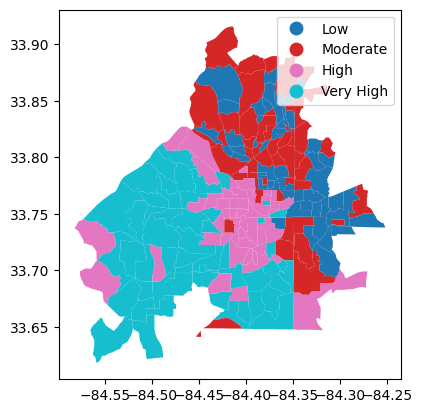

In [619]:
tracts.plot(column='priority_label', legend=True)

In [620]:
priority_table = tracts[
    tracts['priority_label'] == 'Very High'
][[
    'tract_id',
    'need_score',
    'PvrtyRt',
    'TrcSNAP',
    'food_business_count',
    'marta_access_count'
]].sort_values('need_score', ascending=False)

priority_table.head(10)

,tract_id,need_score,PvrtyRt,TrcSNAP,food_business_count,marta_access_count
17,Census Tract 79,0.736063,0.714767,12.06,0.0,12
22,Census Tract 112.03,0.699775,0.537992,12.76,0.0,10
23,Census Tract 112.04,0.695364,0.537992,12.76,0.0,13
18,Census Tract 80,0.688383,0.553191,12.06,0.0,10
73,Census Tract 66.01,0.685420,0.553191,12.76,0.0,23
5,Census Tract 76.03,0.668151,0.553191,12.76,3.0,26
14,Census Tract 78.06,0.664298,0.714767,9.46,0.0,20
89,Census Tract 108.02,0.662726,0.486028,11.86,0.0,10
84,Census Tract 73.01,0.658440,0.486028,11.86,1.0,10
29,Census Tract 78.08,0.655978,0.714767,9.46,4.0,14


In [621]:
def explain(row):
    reasons = []
    if row['TrcSNAP'] > 0.3:
        reasons.append("high SNAP reliance")
    if row['PvrtyRt'] > 0.25:
        reasons.append("high poverty")
    if row['food_business_count'] < 2:
        reasons.append("low food retail access")
    if row['marta_access_count'] < 2:
        reasons.append("limited transit access")
    return ", ".join(reasons)

tracts['reason'] = tracts.apply(explain, axis=1)

## 19. Acquired More Data for Snap Retailer Features

In [622]:
snap = pd.read_csv("../data/snap/snap_retailers.csv")
# Convert to datetime (#### will become NaT)
snap["Latitude"] = pd.to_numeric(snap["Latitude"], errors="coerce")
snap["Longitude"] = pd.to_numeric(snap["Longitude"], errors="coerce")
snap = snap.dropna(subset=["Latitude", "Longitude"])


def classify_store(t):
    t = str(t).lower().strip()

    if t in ["supermarket", "large grocery store", "super store"]:
        return "High"
    elif t in ["medium grocery store", "small grocery store",
               "combination grocery/other", "food buying co-op"]:
        return "Moderate"
    elif t in ["farmers' market", "fruits/veg specialty",
               "meat/poultry specialty", "seafood specialty"]:
        return "Specialty"
    elif t in ["convenience store", "bakery specialty", "delivery route"]:
        return "Low"
    else:
        return "Other"

snap["access_level"] = snap["Store Type"].apply(classify_store)

snap_gdf = gpd.GeoDataFrame(
    snap,
    geometry=gpd.points_from_xy(snap["Longitude"], snap["Latitude"]),
    crs="EPSG:4326"
)

tracts = tracts.to_crs("EPSG:4326")

snap_joined = gpd.sjoin(
    snap_gdf,
    tracts[["tract_id", "geometry"]],
    how="left",
    predicate="within"
)

snap_counts = (
    snap_joined
    .dropna(subset=["tract_id"])
    .groupby(["tract_id", "access_level"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

snap_m = snap_gdf.to_crs(epsg=3857)
bus_m = food_bus_gdf.to_crs(epsg=3857)

joined = gpd.sjoin_nearest(
    snap_m,
    bus_m,
    how="left",
    max_distance=100,
    distance_col="distance_m"
)

snap_verified = joined[joined["distance_m"].notna()].copy()


In [623]:
# make sure both are projected to meters
snap_m = snap_gdf.to_crs(epsg=3857)
food_bus_m = food_bus_gdf.to_crs(epsg=3857)

# match each SNAP retailer to nearest food business license within 100 meters
snap_bus_joined = gpd.sjoin_nearest(
    snap_m,
    food_bus_m,
    how="left",
    max_distance=100,
    distance_col="distance_m"
)

# keep only SNAP retailers with a nearby food business license
snap_verified = snap_bus_joined[snap_bus_joined["distance_m"].notna()].copy()

# check result
print("Original SNAP:", len(snap_gdf))
print("Verified SNAP:", len(snap_verified))
print("Dropped:", len(snap_gdf) - len(snap_verified))

Original SNAP: 2816
Verified SNAP: 951
Dropped: 1865


In [624]:
def classify_store(t):
    t = str(t).lower().strip()

    if t in ["supermarket", "large grocery store", "super store"]:
        return "High"
    elif t in ["medium grocery store", "small grocery store", "combination grocery/other", "food buying co-op"]:
        return "Moderate"
    elif t in ["farmers' market", "fruits/veg specialty", "meat/poultry specialty", "seafood specialty"]:
        return "Specialty"
    elif t in ["convenience store", "bakery specialty", "delivery route"]:
        return "Low"
    else:
        return "Other"

snap_verified["access_level"] = snap_verified["Store Type"].apply(classify_store)
snap_verified["access_level"].value_counts()

access_level
Low          595
Moderate     158
Specialty    108
High          90
Name: count, dtype: int64

In [625]:
# remove old join columns if they exist
for col in ["index_right", "index_left"]:
    if col in snap_verified.columns:
        snap_verified = snap_verified.drop(columns=[col])

# same CRS
snap_verified = snap_verified.to_crs("EPSG:4326")
tracts = tracts.to_crs("EPSG:4326")

# assign each verified SNAP retailer to a tract
snap_joined = gpd.sjoin(
    snap_verified,
    tracts[["tract_id", "geometry"]],
    how="left",
    predicate="within"
)

snap_joined[["Store Name", "Store Type", "access_level", "tract_id"]].head()

,Store Name,Store Type,access_level,tract_id
1,CAMP LEE CONVENIENCE STORE,Convenience Store,Low,Census Tract 66.02
77,A G C Store,Convenience Store,Low,Census Tract 207
115,Big H,Convenience Store,Low,Census Tract 209.02
116,BIG H FOOD MART,Convenience Store,Low,Census Tract 209.02
117,BIG H FOOD MART,Convenience Store,Low,Census Tract 209.02


In [626]:
snap_counts = (
    snap_joined
    .dropna(subset=["tract_id"])
    .groupby(["tract_id", "access_level"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

snap_counts.columns.name = None

for col in ["High", "Moderate", "Specialty", "Low", "Other"]:
    if col not in snap_counts.columns:
        snap_counts[col] = 0

snap_counts["total_snap_stores"] = snap_counts[
    ["High", "Moderate", "Specialty", "Low", "Other"]
].sum(axis=1)

snap_counts["low_access_ratio"] = (
    snap_counts["Low"] / snap_counts["total_snap_stores"]
).fillna(0)

snap_counts["fresh_access_ratio"] = (
    snap_counts[["High", "Moderate", "Specialty"]].sum(axis=1)
    / snap_counts["total_snap_stores"]
).fillna(0)

snap_counts = snap_counts.rename(columns={
    "High": "high_access_count",
    "Moderate": "moderate_access_count",
    "Specialty": "specialty_access_count",
    "Low": "low_access_count",
    "Other": "other_snap_count",
})

snap_counts.head()

,tract_id,high_access_count,low_access_count,moderate_access_count,specialty_access_count,other_snap_count,total_snap_stores,low_access_ratio,fresh_access_ratio
0,Census Tract 1,2,0,0,2,0,4,0.0,1.0
1,Census Tract 10.01,2,0,0,0,0,2,0.0,1.0
2,Census Tract 10.02,0,2,0,0,0,2,1.0,0.0
3,Census Tract 100.07,0,0,1,0,0,1,0.0,1.0
4,Census Tract 103.05,0,0,0,1,0,1,0.0,1.0


In [ ]:
snap_cols = [
    "high_access_count",
    "moderate_access_count",
    "specialty_access_count",
    "low_access_count",
    "other_snap_count",
    "total_snap_stores",
    "low_access_ratio",
    "fresh_access_ratio",
]

tracts = tracts.drop(columns=[col for col in snap_cols if col in tracts.columns])

tracts = tracts.merge(snap_counts, on="tract_id", how="left")

for col in snap_cols:
    tracts[col] = tracts[col].fillna(0)
tracts[["tract_id", "total_snap_stores", "low_access_ratio", "fresh_access_ratio"]].head()

,tract_id,total_snap_stores,low_access_ratio,fresh_access_ratio
0,Census Tract 103.07,0.0,0.000000,0.000000
1,Census Tract 113.06,0.0,0.000000,0.000000
2,Census Tract 60,6.0,0.833333,0.166667
3,Census Tract 61,5.0,1.000000,0.000000
4,Census Tract 76.02,0.0,0.000000,0.000000


## 20. Analysis of Problem + Reccomended Solution


In [628]:
def classify_access(row):
    if row["total_snap_stores"] == 0:
        return "True Food Desert"
    
    elif row["low_access_ratio"] > 0.7:
        return "Low-Quality Access"
    
    elif row["fresh_access_ratio"] > 0.6:
        return "Adequate Fresh Access"
    
    elif row["fresh_access_ratio"] > 0.3:
        return "Limited, Mixed Access"
    
    else:
        return "Moderate Access Gap"

tracts["access_problem_type"] = tracts.apply(classify_access, axis=1)

def recommend_solution(row):
    problem = row["access_problem_type"]

    if problem == "True Food Desert":
        return "Prioritize new grocery development through tax incentives or public-private partnerships."

    elif problem == "Low-Quality Access":
        return "Upgrade existing convenience stores with fresh produce, refrigeration support, and healthy corner store incentives."

    elif problem == "Moderate Access Gap":
        return "Support small and mid-size grocery retailers with fresh inventory expansion and stronger supply consistency."

    elif problem == "Adequate Fresh Access":
        return "Maintain access while monitoring affordability, transit connectivity, and neighborhood equity."

    else:
        return "Conduct further local review and consider mobile markets, SNAP delivery, or transit-based food access support."


tracts["access_problem_type"] = tracts.apply(classify_access_problem, axis=1)
tracts["recommended_solution"] = tracts.apply(recommend_solution, axis=1)

In [629]:
tracts["access_problem_type"].value_counts()


access_problem_type
Low-Quality Access       63
Limited, Mixed Access    59
True Food Desert         47
Adequate Fresh Access    37
Moderate Access Gap       5
Name: count, dtype: int64

In [630]:
tracts.to_file(
    "/Users/savannahimani/FreshFoodAccess_Project/data/processed/tract_level_food_access.geojson",
    driver="GeoJSON"
)

In [641]:
check = gpd.read_file("/Users/savannahimani/FreshFoodAccess_Project/data/processed/tract_level_food_access.geojson")
check[["access_problem_type", "recommended_solution"]].head()

,access_problem_type,recommended_solution
0,True Food Desert,Prioritize new grocery development through tax...
1,True Food Desert,Prioritize new grocery development through tax...
2,Low-Quality Access,Upgrade existing convenience stores with fresh...
3,Low-Quality Access,Upgrade existing convenience stores with fresh...
4,True Food Desert,Prioritize new grocery development through tax...


In [632]:
check = gpd.read_file(
    "/Users/savannahimani/FreshFoodAccess_Project/data/processed/tract_level_food_access.geojson"
)

check["access_problem_type"].value_counts()

access_problem_type
Low-Quality Access       63
Limited, Mixed Access    59
True Food Desert         47
Adequate Fresh Access    37
Moderate Access Gap       5
Name: count, dtype: int64

In [633]:
from pathlib import Path

output_path = Path("../data/processed/tract_level_food_access.geojson")
output_path.parent.mkdir(parents=True, exist_ok=True)

tracts.to_file(output_path, driver="GeoJSON")


In [634]:
check = gpd.read_file("../data/processed/tract_level_food_access.geojson")
check.columns

Index(['tract_id', 'FID', 'GEOID', 'NAME', 'County_Nam', 'State_Name',
       'P0010001', 'Longitude', 'Latitude', 'Shape__Are', 'Shape__Len', 'NPU',
       'Shape__Area', 'Shape__Length', 'PvrtyRt', 'TrcSNAP', 'LILAT_1A1',
       'LILAT_A', 'LILAT_1A2', 'LILAT_V', 'has_lila', 'food_business_count',
       'marta_access_count', 'LAhalf10', 'TrcSNAP_scaled', 'PvrtyRt_scaled',
       'LAhalf10_scaled', 'food_business_count_scaled',
       'marta_access_count_scaled', 'food_business_gap', 'transit_gap',
       'need_score', 'priority_level', 'priority_label', 'reason',
       'high_access_count', 'low_access_count', 'moderate_access_count',
       'specialty_access_count', 'other_snap_count', 'total_snap_stores',
       'low_access_ratio', 'fresh_access_ratio', 'access_problem_type',
       'recommended_solution', 'geometry'],
      dtype='str')

In [ ]:
tracts["access_problem_type"] = tracts.apply(classify_access_problem, axis=1)
tracts["recommended_solution"] = tracts.apply(recommend_solution, axis=1)

In [636]:
tracts.to_file(
    "../data/processed/tract_level_food_access.geojson",
    driver="GeoJSON"
)

In [637]:
check = gpd.read_file("/Users/savannahimani/FreshFoodAccess_Project/data/processed/tract_level_food_access.geojson")

check.columns

Index(['tract_id', 'FID', 'GEOID', 'NAME', 'County_Nam', 'State_Name',
       'P0010001', 'Longitude', 'Latitude', 'Shape__Are', 'Shape__Len', 'NPU',
       'Shape__Area', 'Shape__Length', 'PvrtyRt', 'TrcSNAP', 'LILAT_1A1',
       'LILAT_A', 'LILAT_1A2', 'LILAT_V', 'has_lila', 'food_business_count',
       'marta_access_count', 'LAhalf10', 'TrcSNAP_scaled', 'PvrtyRt_scaled',
       'LAhalf10_scaled', 'food_business_count_scaled',
       'marta_access_count_scaled', 'food_business_gap', 'transit_gap',
       'need_score', 'priority_level', 'priority_label', 'reason',
       'high_access_count', 'low_access_count', 'moderate_access_count',
       'specialty_access_count', 'other_snap_count', 'total_snap_stores',
       'low_access_ratio', 'fresh_access_ratio', 'access_problem_type',
       'recommended_solution', 'geometry'],
      dtype='str')

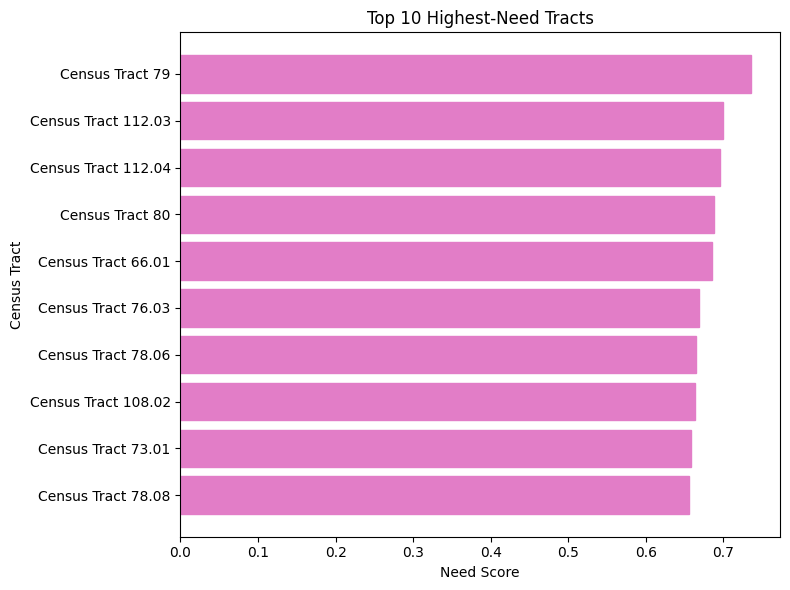

In [ ]:
top10 = (
    tracts[['tract_id', 'need_score', 'priority_level']]
    .sort_values('need_score', ascending=False)
    .head(10)
    .sort_values('need_score')  # for horizontal bar ordering
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

bars = plt.barh(top10['tract_id'].astype(str), top10['need_score'])

color_map = {
    'Low': '#b0c4de',
    'Moderate': '#87ceeb',
    'High': '#4682b4',
    'Very High': "#e27dc7"
}

for i, level in enumerate(top10['priority_level']):
    bars[i].set_color(color_map[level])

plt.xlabel('Need Score')
plt.ylabel('Census Tract')
plt.title('Top 10 Highest-Need Tracts')

plt.tight_layout()
plt.show()

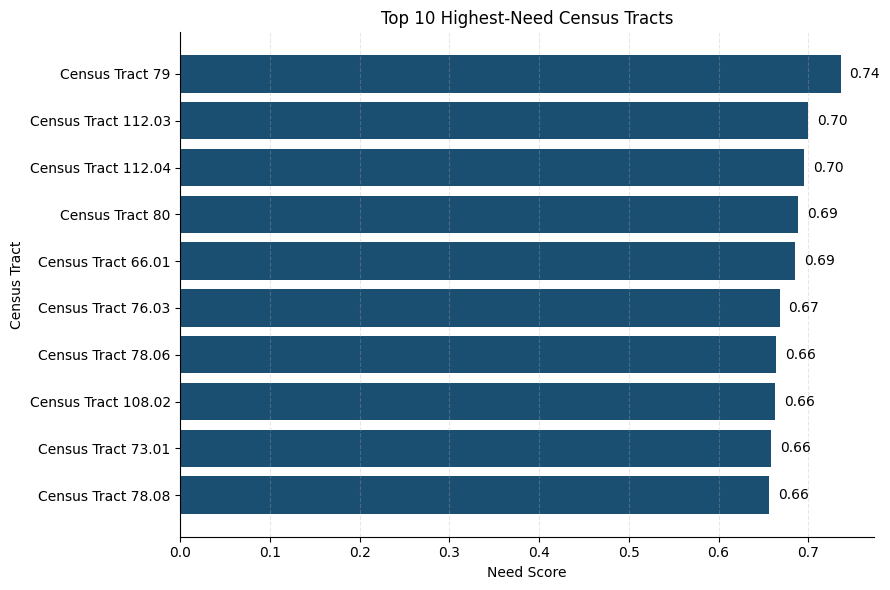

In [ ]:
import matplotlib.pyplot as plt

top10 = (
    tracts[['tract_id', 'need_score', 'priority_level']]
    .sort_values('need_score', ascending=False)
    .head(10)
    .sort_values('need_score') 
)


color_map = {
    'Low': '#D6EAF8',
    'Moderate': '#5DADE2',
    'High': '#2E86C1',
    'Very High': '#1B4F72'
}

colors = top10['priority_level'].map(color_map)


plt.figure(figsize=(9,6))
bars = plt.barh(
    top10['tract_id'].astype(str),
    top10['need_score'],
    color=colors
)


plt.xlabel('Need Score')
plt.ylabel('Census Tract')
plt.title('Top 10 Highest-Need Census Tracts')


plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().spines[['top','right']].set_visible(False)

for i, v in enumerate(top10['need_score']):
    plt.text(v + 0.01, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()

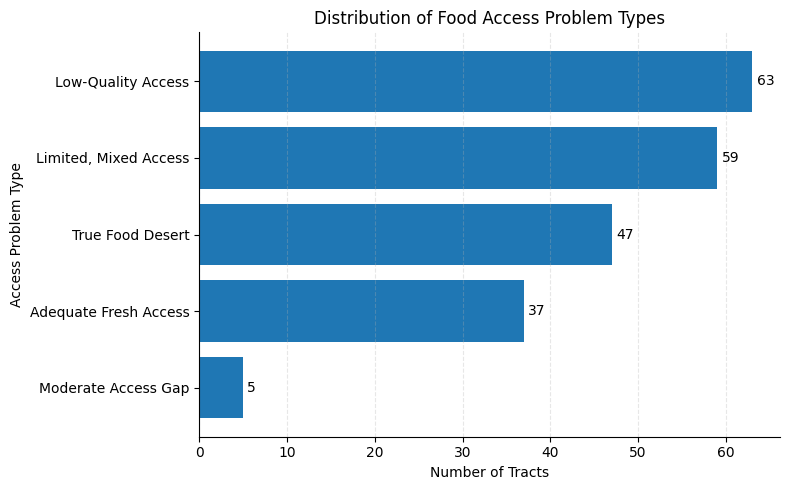

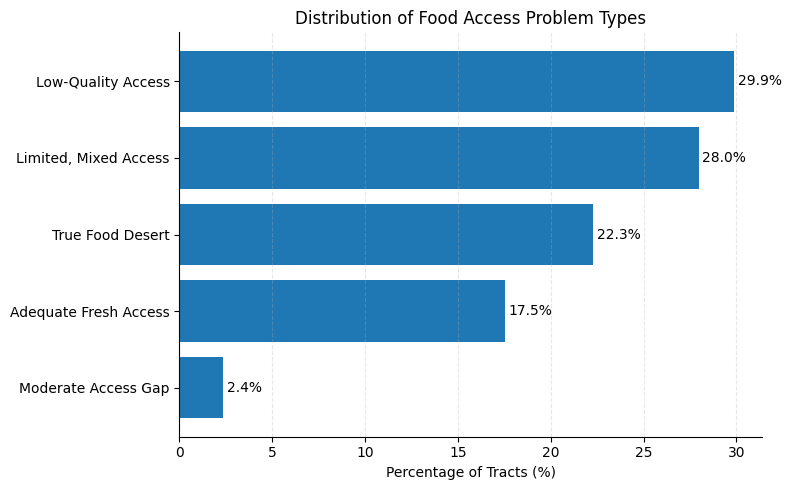

In [ ]:
import matplotlib.pyplot as plt

counts = check["access_problem_type"].value_counts()

plt.figure(figsize=(8,5))

bars = plt.barh(counts.index, counts.values)


plt.xlabel('Number of Tracts')
plt.ylabel('Access Problem Type')
plt.title('Distribution of Food Access Problem Types')

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().spines[['top','right']].set_visible(False)


for i, v in enumerate(counts.values):
    plt.text(v + 0.5, i, str(v), va='center')

plt.tight_layout()
plt.show()
percent = counts / counts.sum() * 100

plt.figure(figsize=(8,5))
bars = plt.barh(percent.index, percent.values)

plt.xlabel('Percentage of Tracts (%)')
plt.title('Distribution of Food Access Problem Types')

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.gca().spines[['top','right']].set_visible(False)

for i, v in enumerate(percent.values):
    plt.text(v + 0.2, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()